Nama    : I Made Telaga Dwiraditya \
ID      : CDCC008D6Y2707 \
Kelas   : CDC-33

# *Import Library*

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
from datasets import load_dataset

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# *Data Wragling*

## *Gather Dataset*

In [2]:
# Dataset 1: dair-ai/emotion
print("\n[1/2] Mengunduh dair-ai/emotion...")
try:
    ds_emotion = load_dataset("dair-ai/emotion", "unsplit", split="train")
except ValueError:
    ds_emotion = load_dataset("dair-ai/emotion", split="train")

df_emotion         = ds_emotion.to_pandas()[["text"]]
df_emotion["source"] = "dair-ai/emotion"

# Dataset 2: google-research-datasets/go_emotions
print("[2/2] Mengunduh google-research-datasets/go_emotions...")
ds_go            = load_dataset("google-research-datasets/go_emotions", "simplified", split="train")
df_go            = ds_go.to_pandas()[["text"]]
df_go["source"]  = "go_emotions"

# Merge kedua dataset
df_raw = pd.concat([df_emotion, df_go], ignore_index=True)

print(f"\nTotal data mentah : {len(df_raw)} baris")
print(f"Kolom             : {list(df_raw.columns)}")
print("\nSample data:")
print(df_raw.head(5).to_string(index=False))


[1/2] Mengunduh dair-ai/emotion...


[2/2] Mengunduh google-research-datasets/go_emotions...

Total data mentah : 460219 baris
Kolom             : ['text', 'source']

Sample data:
                                                                                                                                                    text          source
                                        i feel awful about it too because it s my job to get him in a position to succeed and it just didn t happen here dair-ai/emotion
                                                                                                                                   im alone i feel awful dair-ai/emotion
ive probably mentioned this before but i really do feel proud of myself for actually keeping up with my new years resolution of monthly and weekly goals dair-ai/emotion
                                                                                                                i was feeling a little low few days back dair-ai/emotion
            

## *Assessing Dataset*

In [3]:
# --- Missing value ---
print("\n[ Missing Value ]")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({
    "jumlah_missing" : missing,
    "persentase (%)" : missing_pct
})
print(missing_df)

# --- Duplikat ---
print("\n[ Duplikat ]")
n_dup = df_raw.duplicated(subset=["text"]).sum()
print(f"Jumlah baris duplikat : {n_dup:,}")
print(f"Persentase duplikat   : {n_dup / len(df_raw) * 100:.2f}%")

# --- Info umum ---
print("\n[ Info Umum ]")
print(f"Distribusi sumber data:")
print(df_raw["source"].value_counts().to_string())


[ Missing Value ]
        jumlah_missing  persentase (%)
text                 0             0.0
source               0             0.0

[ Duplikat ]
Jumlah baris duplikat : 23,170
Persentase duplikat   : 5.03%

[ Info Umum ]
Distribusi sumber data:
source
dair-ai/emotion    416809
go_emotions         43410


## *Cleaning Dataset*

### Hapus Duplikat

In [4]:
# Hapus missing value & duplikat
print("\n[i] Menghapus duplikat...")

df_clean = df_raw.drop_duplicates(subset=["text"]).reset_index(drop=True)

print(f"Sebelum : {len(df_raw):} baris")
print(f"Sesudah : {len(df_clean):} baris")
print(f"Dihapus : {len(df_raw) - len(df_clean):} baris")


[i] Menghapus duplikat...
Sebelum : 460219 baris
Sesudah : 437049 baris
Dihapus : 23170 baris


### *Cleaning Text*

In [5]:
# Cleaning Text & Expand contractions
contractions_dict = {
    # I (dengan apostrof)
    "i'm"       : "i am",
    "i've"      : "i have",
    "i'll"      : "i will",
    "i'd"       : "i would",
    # I (tanpa apostrof — typo/informal)
    "im"        : "i am",
    "ive"       : "i have",
    #"ill"       : "i will",   # hati-hati: "ill" juga berarti sakit
    #"id"        : "i would",  # hati-hati: "id" juga bisa noun
    # you
    "you're"    : "you are",
    "you've"    : "you have",
    "you'll"    : "you will",
    "you'd"     : "you would",
    "youre"     : "you are",
    "youve"     : "you have",
    "youll"     : "you will",
    "youd"      : "you would",
    # he
    "he's"      : "he is",
    "he'll"     : "he will",
    "he'd"      : "he would",
    "hes"       : "he is",
    "hed"       : "he would",
    # she
    "she's"     : "she is",
    "she'll"    : "she will",
    "she'd"     : "she would",
    "shes"      : "she is",
    "shed"      : "she would",
    # it
    "it's"      : "it is",
    "it'll"     : "it will",
    "it'd"      : "it would",
    #"its"       : "it is",    # hati-hati: "its" juga bisa possessive
    # we
    "we're"     : "we are",
    "we've"     : "we have",
    "we'll"     : "we will",
    "we'd"      : "we would",
    #"were"      : "we are",   # hati-hati: "were" juga past tense "be"
    "weve"      : "we have",
    "wed"       : "we would",
    # they
    "they're"   : "they are",
    "they've"   : "they have",
    "they'll"   : "they will",
    "they'd"    : "they would",
    "theyre"    : "they are",
    "theyve"    : "they have",
    "theyll"    : "they will",
    "theyd"     : "they would",
    # negations (dengan apostrof)
    "aren't"    : "are not",
    "isn't"     : "is not",
    "wasn't"    : "was not",
    "weren't"   : "were not",
    "don't"     : "do not",
    "doesn't"   : "does not",
    "didn't"    : "did not",
    "won't"     : "will not",
    "wouldn't"  : "would not",
    "can't"     : "can not",
    "cannot"    : "can not",
    "couldn't"  : "could not",
    "shouldn't" : "should not",
    "hadn't"    : "had not",
    "hasn't"    : "has not",
    "haven't"   : "have not",
    "mustn't"   : "must not",
    "needn't"   : "need not",
    "daren't"   : "dare not",
    "shan't"    : "shall not",
    # negations (tanpa apostrof — typo/informal)
    "arent"     : "are not",
    "isnt"      : "is not",
    "wasnt"     : "was not",
    "werent"    : "were not",
    "dont"      : "do not",
    "doesnt"    : "does not",
    "didnt"     : "did not",
    "wont"      : "will not",
    "wouldnt"   : "would not",
    "cant"      : "can not",
    "couldnt"   : "could not",
    "shouldnt"  : "should not",
    "hadnt"     : "had not",
    "hasnt"     : "has not",
    "havent"    : "have not",
    "mustnt"    : "must not",
    # have/would combinations (dengan apostrof)
    "that've"   : "that have",
    "who've"    : "who have",
    "would've"  : "would have",
    "could've"  : "could have",
    "should've" : "should have",
    "might've"  : "might have",
    "must've"   : "must have",
    # have/would combinations (tanpa apostrof)
    "wouldve"   : "would have",
    "couldve"   : "could have",
    "shouldve"  : "should have",
    "mightve"   : "might have",
    "mustve"    : "must have",
    # misc (dengan apostrof)
    "that's"    : "that is",
    "that'd"    : "that would",
    "there's"   : "there is",
    "there're"  : "there are",
    "there'll"  : "there will",
    "who's"     : "who is",
    "who'd"     : "who would",
    "who'll"    : "who will",
    "what's"    : "what is",
    "what're"   : "what are",
    "what'll"   : "what will",
    "what'd"    : "what did",
    "where's"   : "where is",
    "where'd"   : "where did",
    "when's"    : "when is",
    "why's"     : "why is",
    "how's"     : "how is",
    "how'd"     : "how did",
    "how'll"    : "how will",
    "let's"     : "let us",
    "y'all"     : "you all",
    # misc (tanpa apostrof)
    "thats"     : "that is",
    "theres"    : "there is",
    "whos"      : "who is",
    "whats"     : "what is",
    "wheres"    : "where is",
    "whens"     : "when is",
    "whys"      : "why is",
    "hows"      : "how is",
    "lets"      : "let us",
    "yall"      : "you all",
    # informal/slang
    "gonna"     : "going to",
    "wanna"     : "want to",
    "gotta"     : "got to",
    "kinda"     : "kind of",
    "sorta"     : "sort of",
    "dunno"     : "do not know",
    "ain't"     : "is not",
    "aint"      : "is not",
    "tryna"     : "trying to",
    "hafta"     : "have to",
    "oughta"    : "ought to",
    "supposta"  : "supposed to",
    "useta"     : "used to",
}

contractions_pattern = re.compile(
    r'\b(' + '|'.join(re.escape(k) for k in contractions_dict.keys()) + r')\b',
    re.IGNORECASE
)

def expand_contractions(text):
    def replace(match):
        token = match.group(0).lower()
        return contractions_dict.get(token, token)
    return contractions_pattern.sub(replace, text)


In [6]:
def clean_text_v1(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)   # hapus URL
    text = expand_contractions(text)               # expand contractions
    text = re.sub(r"[^a-zA-Z\s]", " ", text)      # hapus karakter non-huruf
    text = re.sub(r"\s+", " ", text).strip()       # rapikan spasi
    return text

def clean_text_v2(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)   # hapus URL
    text = expand_contractions(text)               # expand contractions
    text = re.sub(r"[^\w\s]", " ", text)          # hapus tanda baca
    text = re.sub(r"[^a-zA-Z\s]", " ", text)      # hapus karakter non-huruf
    text = re.sub(r"\s+", " ", text).strip()       # rapikan spasi
    return text

print("\n[ii] Cleaning teks...")
df_clean["text_clean_v1"] = df_clean["text"].apply(clean_text_v1)   # tanpa hapus tanda baca
df_clean["text_clean_v2"] = df_clean["text"].apply(clean_text_v2)   # dengan hapus tanda baca


[ii] Cleaning teks...


### *Filtering (Breakup Score)*

In [9]:
# Filter breakup score
breakup_keywords = [
    # RELATIONSHIP TERMS
    "boyfriend", "girlfriend", "bf", "gf", "partner",
    "husband", "wife", "fiance", "fiancee",
    "lover", "significant other", "spouse",
    "crush", "dating", "relationship",
    "romantic relationship", "long distance relationship",
    "ldr", "situationship",
    # BREAKUP TERMS
    "breakup", "break up", "broke up", "broken up",
    "split up", "ended things", "ended our relationship",
    "ended our friendship", "called it quits",
    "dumped", "got dumped", "left me", "left him",
    "left her", "walked away", "abandoned me",
    "moved on", "moving on", "separated",
    "divorce", "divorced", "separation",
    # EX / PAST RELATIONSHIP
    "my ex", "ex boyfriend", "ex girlfriend",
    "former boyfriend", "former girlfriend",
    "past relationship", "past lover",
    "previous relationship",
    # HEARTBREAK / LOSS
    "heartbroken", "broken heart", "hurt",
    "hurt me", "emotionally hurt",
    "devastated", "shattered", "crushed",
    "betrayed", "abandoned", "rejected",
    "unloved", "unwanted", "lonely",
    "miss him", "miss her", "miss my ex",
    "can not forget", "still love", "still miss",
    "lost him", "lost her", "can not move on",
    "crying over", "thinking about my ex",
    "thinking about him", "thinking about her",
    # CHEATING / BETRAYAL
    "cheated", "cheating", "affair",
    "unfaithful", "lied to me",
    "betrayed my trust", "two timed",
    "seeing someone else",
    "talking to another girl",
    "talking to another guy",
    # TOXIC RELATIONSHIP
    "toxic relationship", "manipulative",
    "emotionally abusive", "gaslight",
    "gaslighting", "controlling",
    "possessive", "ignored me",
    "ghosted", "blocked me",
    "silent treatment", "red flag",
    "used me", "took advantage of me",
    # ARGUMENT / CONFLICT
    "argument", "argued", "fight",
    "fighting", "fight with my boyfriend",
    "fight with my girlfriend",
    "constant fighting", "we fought",
    "we keep arguing", "misunderstanding",
    "conflict in relationship",
    # ANXIETY AFTER BREAKUP
    "overthinking him", "overthinking her",
    "anxious about relationship",
    "relationship anxiety", "fear of losing",
    "afraid to lose him", "afraid to lose her",
    "worried he will leave", "worried she will leave",
    "attachment issues", "clingy", "insecure relationship",
    # ACCEPTANCE / HEALING
    "healing", "recovering", "trying to move on",
    "self love", "letting go", "finding peace", "closure",
    "finally okay", "feeling better", "accepting the breakup",
    "learning to be alone", "working on myself",
    "focusing on myself", "becoming independent",
    # SOCIAL MEDIA / MODERN TERMS
    "seen zoned", "friend zoned", "unfollowed me",
    "blocked me", "removed me", "texted my ex",
    "stalk my ex", "checking his profile", "checking her profile",
    # COMMON EXPRESSIONS
    "he does not love me", "she does not love me",
    "he stopped talking to me", "she stopped talking to me",
    "he lost feelings", "she lost feelings",
    "i miss my relationship", "i feel alone after breakup",
    "i can not stop thinking about him",
    "i can not stop thinking about her",
    "i want him back", "i want her back",
    "i still care about him", "i still care about her"
]

breakup_anger_keywords = [
    "cheated", "cheating", "affair", "unfaithful", "lied to me",
    "betrayed", "betrayed my trust", "two timed", "manipulative",
    "gaslighting", "controlling", "toxic relationship", "emotionally abusive",
    "used me", "took advantage of me", "ghosted", "blocked me",
    "silent treatment", "red flag", "possessive", "ignored me",
    "argument", "argued", "fight", "fighting", "we fought",
    "constant fighting", "endless arguments"
]

breakup_anxiety_keywords = [
    "miss him", "miss her", "miss my ex", "still love", "still miss",
    "can not forget", "can not move on", "thinking about him",
    "thinking about her", "thinking about my ex", "i want him back",
    "i want her back", "i still care about him", "i still care about her",
    "overthinking him", "overthinking her", "relationship anxiety",
    "fear of losing", "afraid to lose him", "afraid to lose her",
    "worried he will leave", "worried she will leave",
    "attachment issues", "clingy", "insecure relationship",
    "heartbroken", "broken heart", "devastated", "shattered", "crushed",
    "lonely", "unloved", "unwanted", "lost him", "lost her",
    "crying over", "stalk my ex", "checking his profile", "checking her profile"
]

breakup_acceptance_keywords = [
    "healing", "recovering", "trying to move on", "self love",
    "letting go", "finding peace", "closure", "finally okay",
    "feeling better", "accepting the breakup", "learning to be alone",
    "working on myself", "focusing on myself", "becoming independent",
    "starting over", "fresh start", "new chapter", "new beginning",
    "getting over him", "getting over her", "slowly healing"
]

In [10]:
def get_breakup_score(text, keywords):
    text = str(text).lower()
    score = 0
    for keyword in keywords:
        pattern = r"\b" + re.escape(keyword.lower()) + r"\b"
        if re.search(pattern, text):
            score += 1
    return score

print("\n[iii] Menghitung breakup score...")
df_clean["breakup_score"] = df_clean["text_clean_v2"].apply(
    lambda x: get_breakup_score(x, breakup_keywords)
)

df_filtered = df_clean[
    df_clean["breakup_score"] >= 2
].copy().reset_index(drop=True)

print(f"Sebelum filter : {len(df_clean):} baris")
print(f"Sesudah filter : {len(df_filtered):} baris")
print(f"Dihapus        : {len(df_clean) - len(df_filtered):} baris")


[iii] Menghitung breakup score...
Sebelum filter : 437049 baris
Sesudah filter : 1812 baris
Dihapus        : 435237 baris


# *EDA & Visualization*

## *Emotion Lexicon (Feature Engineering*)

In [11]:
# Dictionary
# bobot per kata: semakin kuat ekspresi emosi, semakin tinggi bobotnya
anger_words = {
    # bobot tinggi (ekspresi kuat)
    "furious"      : 3, "rage"         : 3, "livid"        : 3,
    "fuming"       : 3, "outrage"      : 3, "hate"         : 3,
    "loathe"       : 3, "despise"      : 3, "screamed"     : 3,
    "yelled"       : 3, "betrayed"     : 3, "manipulative" : 3,
    "gaslighting"  : 3, "abusive"      : 3, "narcissist"   : 3,
    # bobot sedang
    "angry"        : 2, "anger"        : 2, "bitter"       : 2,
    "resentful"    : 2, "frustrated"   : 2, "irritated"    : 2,
    "disgusted"    : 2, "cruel"        : 2, "heartless"    : 2,
    "toxic"        : 2, "controlling"  : 2, "lied"         : 2,
    "cheated"      : 2, "unfaithful"   : 2, "selfish"      : 2,
    # bobot rendah (ekspresi umum)
    "mad"          : 1, "upset"        : 1, "annoyed"      : 1,
    "piss"         : 1, "sick"         : 1, "done"         : 1,
    "fed"          : 1, "trigger"      : 1, "grudge"       : 1,
    "disappoint"   : 1, "resent"       : 1, "hurt"         : 1,
    "salty"        : 1, "used"         : 1, "disrespect"   : 1,
    "humiliate"    : 1, "betray"       : 1, "annoy"        : 1,
    "frustrate"    : 1, "fury"         : 1, "irritate"     : 1,
}

anxiety_words = {
    # bobot tinggi
    "terrified"    : 3, "panic"        : 3, "paranoid"     : 3,
    "desperate"    : 3, "hopeless"     : 3, "obsess"       : 3,
    "spiral"       : 3, "shattered"    : 3, "helpless"     : 3,
    "sleepless"    : 3, "dread"        : 3,
    # bobot sedang
    "anxious"      : 2, "anxiety"      : 2, "afraid"       : 2,
    "insecure"     : 2, "overthink"    : 2, "overwhelm"    : 2,
    "lonely"       : 2, "empty"        : 2, "numb"         : 2,
    "broken"       : 2, "lost"         : 2, "hollow"       : 2,
    "crying"       : 2, "weeping"      : 2, "tears"        : 2,
    "clingy"       : 2, "stalk"        : 2, "attachment"   : 2,
    # bobot rendah
    "worry"        : 1, "nervous"      : 1, "stress"       : 1,
    "restless"     : 1, "uneasy"       : 1, "unsure"       : 1,
    "confuse"      : 1, "doubt"        : 1, "hesitate"     : 1,
    "stuck"        : 1, "fear"         : 1, "worried"      : 1,
    "miss"         : 1, "still"        : 1, "forget"       : 1,
    "thinking"     : 1, "checking"     : 1, "cling"        : 1,
    "scare"        : 1,
}

acceptance_words = {
    # bobot tinggi
    "forgive"      : 3, "closure"      : 3, "rediscover"   : 3,
    "gratitude"    : 3, "grateful"     : 3, "unbothered"   : 3,
    "confident"    : 3, "proud"        : 3, "clarity"      : 3,
    # bobot sedang
    "accept"       : 2, "heal"         : 2, "peace"        : 2,
    "recover"      : 2, "independent"  : 2, "rebuild"      : 2,
    "forward"      : 2, "calm"         : 2, "free"         : 2,
    "growth"       : 2, "strong"       : 2, "release"      : 2,
    "relief"       : 2, "smile"        : 2, "happy"        : 2,
    "joy"          : 2, "comfortable"  : 2, "indifferent"  : 2,
    # bobot rendah
    "move"         : 1, "okay"         : 1, "realize"      : 1,
    "learn"        : 1, "better"       : 1, "start"        : 1,
    "understand"   : 1, "grow"         : 1, "enough"       : 1,
    "change"       : 1, "finally"      : 1, "letting"      : 1,
    "finding"      : 1, "feeling"      : 1, "accepting"    : 1,
    "working"      : 1, "focusing"     : 1, "becoming"     : 1,
    "laugh"        : 1,
}

emotion_dict = {
    "anger"      : anger_words,
    "anxiety"    : anxiety_words,
    "acceptance" : acceptance_words,
}

In [12]:
# Hitung probabilitas emosi
def preprocess_for_emotion(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()

def detect_structure_emotion(text):
    text = str(text).lower()
    scores = {"anger": 0, "anxiety": 0, "acceptance": 0}

    # pola kalimat tanya → anxiety
    if re.search(r"\b(why|what if|how could|where did|when will)\b", text):
        scores["anxiety"] += 2

    # pola eksklamasi / tuduhan → anger
    if re.search(r"\b(he lied|she lied|how dare|i hate|never again|so done)\b", text):
        scores["anger"] += 2

    # pola resolusi / pernyataan positif → acceptance
    if re.search(r"\b(i am okay|i am fine|i am better|i am moving|i am healing|i am done crying)\b", text):
        scores["acceptance"] += 2

    # subjek "he/she" + verb negatif → anger
    if re.search(r"\b(he|she)\b.{0,20}\b(left|lied|cheated|hurt|ignored|blocked|ghosted)\b", text):
        scores["anger"] += 1

    # subjek "i" + verb longing → anxiety
    if re.search(r"\bi\b.{0,20}\b(miss|wish|hope|want|need|think about)\b", text):
        scores["anxiety"] += 1

    return scores

def calculate_emotion_probabilities(text):
    tokens       = preprocess_for_emotion(text)
    token_counts = Counter(tokens)

    scores = {"anger": 0, "anxiety": 0, "acceptance": 0}

    # Layer 1: weighted lexicon
    for emotion, vocab_dict in emotion_dict.items():
        for word, weight in vocab_dict.items():
            if word in token_counts:
                scores[emotion] += token_counts[word] * weight

    # Layer 2: breakup keyword context
    if all(s == 0 for s in scores.values()):
        text_lower = str(text).lower()
        for kw in breakup_anger_keywords:
            if re.search(r"\b" + re.escape(kw) + r"\b", text_lower):
                scores["anger"] += 1
        for kw in breakup_anxiety_keywords:
            if re.search(r"\b" + re.escape(kw) + r"\b", text_lower):
                scores["anxiety"] += 1
        for kw in breakup_acceptance_keywords:
            if re.search(r"\b" + re.escape(kw) + r"\b", text_lower):
                scores["acceptance"] += 1

    # Layer 3: sentence structure heuristic
    if all(s == 0 for s in scores.values()):
        structure_scores = detect_structure_emotion(text)
        for emotion in scores:
            scores[emotion] += structure_scores[emotion]

    # acceptance penalty
    negative_strength = scores["anger"] + scores["anxiety"]
    if negative_strength > 0:
        scores["acceptance"] *= 0.35

    # smoothing
    for emotion in scores:
        scores[emotion] += 0.01

    # softmax
    exp_scores = {e: np.exp(s) for e, s in scores.items()}
    total      = sum(exp_scores.values())
    probs      = {f"{e}_prob": exp_scores[e] / total for e in exp_scores}

    return pd.Series(probs)

print("\n[i] Menghitung probabilitas emosi...")
emotion_probs = df_filtered["text_clean_v2"].apply(calculate_emotion_probabilities)
emotion_cols = ["anger_prob", "anxiety_prob", "acceptance_prob"]

df_eda = pd.concat(
    [
        df_filtered[[
            "text_clean_v1", "text_clean_v2",
            "source", "breakup_score"
        ]].reset_index(drop=True),
        emotion_probs.reset_index(drop=True)
    ],
    axis=1
)


[i] Menghitung probabilitas emosi...


In [19]:
# Predicted emotion & confidence
CONFIDENCE_THRESHOLD = 0.34

def predict_emotion(row):
    probs = {
        "anger"      : row["anger_prob"],
        "anxiety"    : row["anxiety_prob"],
        "acceptance" : row["acceptance_prob"],
    }
    max_emotion = max(probs, key=probs.get)
    max_prob    = probs[max_emotion]

    if max_prob < CONFIDENCE_THRESHOLD:
        return "unclear"

    return max_emotion

df_eda["predicted_emotion"]  = df_eda.apply(predict_emotion, axis=1)
df_eda["emotion_confidence"] = df_eda[emotion_cols].max(axis=1)

## *Visualization (Bar Chart)*

In [20]:
# Statistik EDA
print("\n[ Distribusi Predicted Emotion ]")
emotion_dist = df_eda["predicted_emotion"].value_counts()
print(emotion_dist.to_string())

print(f"\n[ Rata-rata Confidence per Emosi ]")
print(df_eda.groupby("predicted_emotion")["emotion_confidence"].mean().round(4).to_string())

print(f"\n[ Rata-rata Probabilitas per Kolom ]")
print(df_eda[emotion_cols].mean().round(4).to_string())

print(f"\n[ Distribusi Sumber Data ]")
print(df_eda["source"].value_counts().to_string())


[ Distribusi Predicted Emotion ]
predicted_emotion
anger         679
anxiety       527
acceptance    344
unclear       262

[ Rata-rata Confidence per Emosi ]
predicted_emotion
acceptance    0.6407
anger         0.6918
anxiety       0.7150
unclear       0.3333

[ Rata-rata Probabilitas per Kolom ]
anger_prob         0.3828
anxiety_prob       0.3488
acceptance_prob    0.2684

[ Distribusi Sumber Data ]
source
dair-ai/emotion    1736
go_emotions          76


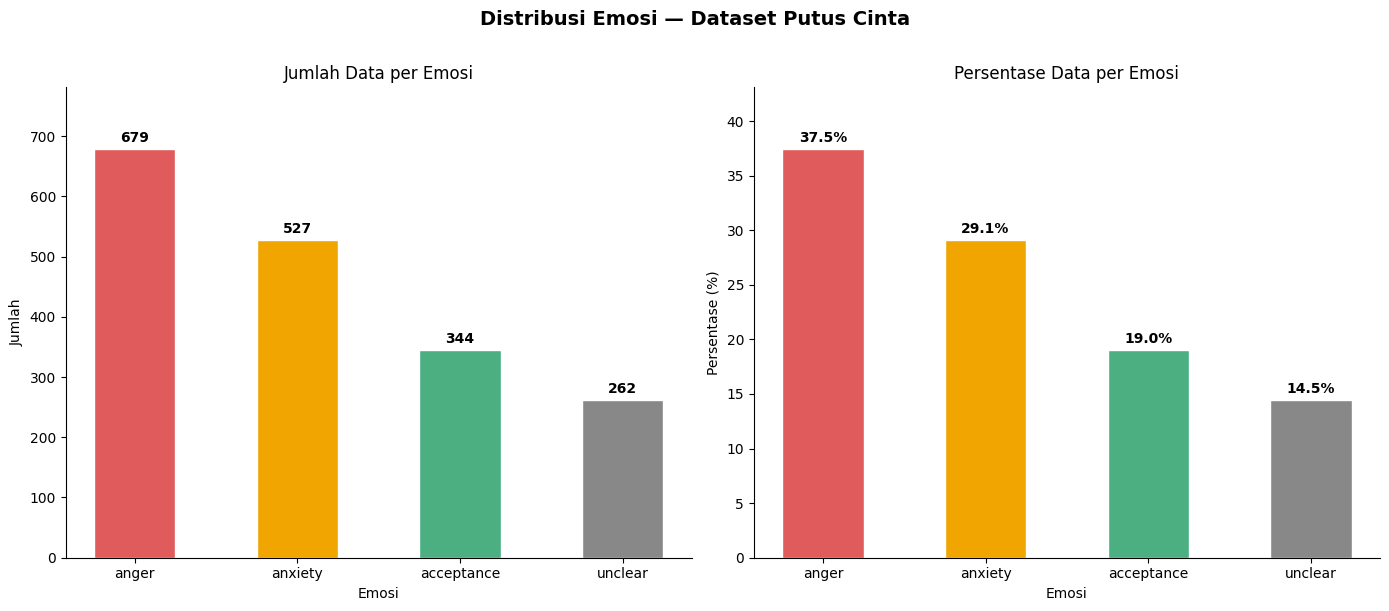

Visualisasi disimpan sebagai: 'distribusi_emosi.png'


In [21]:
# Visualisasi bar chart distribusi emosi
emotion_counts  = df_eda["predicted_emotion"].value_counts()
emotion_labels  = emotion_counts.index.tolist()
emotion_values  = emotion_counts.values.tolist()
emotion_colors  = {
    "anger"      : "#E05C5C",
    "anxiety"    : "#F0A500",
    "acceptance" : "#4CAF82"
}
bar_colors = [emotion_colors.get(e, "#888888") for e in emotion_labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Distribusi Emosi — Dataset Putus Cinta", fontsize=14, fontweight="bold", y=1.01)

# --- Bar chart: jumlah ---
ax1 = axes[0]
bars = ax1.bar(emotion_labels, emotion_values, color=bar_colors, edgecolor="white", width=0.5)
ax1.set_title("Jumlah Data per Emosi", fontsize=12)
ax1.set_xlabel("Emosi")
ax1.set_ylabel("Jumlah")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, val in zip(bars, emotion_values):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(emotion_values) * 0.01,
        f"{val:,}", ha="center", va="bottom", fontsize=10, fontweight="bold"
    )
ax1.set_ylim(0, max(emotion_values) * 1.15)
ax1.spines[["top", "right"]].set_visible(False)

# --- Bar chart: persentase ---
ax2 = axes[1]
total          = sum(emotion_values)
emotion_pcts   = [v / total * 100 for v in emotion_values]
bars2 = ax2.bar(emotion_labels, emotion_pcts, color=bar_colors, edgecolor="white", width=0.5)
ax2.set_title("Persentase Data per Emosi", fontsize=12)
ax2.set_xlabel("Emosi")
ax2.set_ylabel("Persentase (%)")
for bar, pct in zip(bars2, emotion_pcts):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(emotion_pcts) * 0.01,
        f"{pct:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold"
    )
ax2.set_ylim(0, max(emotion_pcts) * 1.15)
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("distribusi_emosi.png", dpi=150, bbox_inches="tight")
plt.show()
print("Visualisasi disimpan sebagai: 'distribusi_emosi.png'")

# Export Dataset

In [22]:
final_cols = [
    "text_clean_v1", "text_clean_v2", "anger_prob", "anxiety_prob", "acceptance_prob",
    "predicted_emotion", "emotion_confidence"
]

output_filename = "emotion_label_dataset.xlsx"
df_eda[final_cols].to_excel(output_filename, index=False)
print(f"\nDataset disimpan sebagai: '{output_filename}'")
print(f"Total baris : {len(df_eda):,}")
print(f"Total kolom : {len(final_cols)}")


Dataset disimpan sebagai: 'emotion_label_dataset.xlsx'
Total baris : 1,812
Total kolom : 7


In [23]:
pd.read_excel("emotion_label_dataset.xlsx")

,text_clean_v1,text_clean_v2,anger_prob,anxiety_prob,acceptance_prob,predicted_emotion,emotion_confidence
0,i am feeling unloved and unwanted and as if th...,i am feeling unloved and unwanted and as if th...,0.211942,0.211942,0.576117,acceptance,0.576117
1,i am fighting with my mind trying to tell myse...,i am fighting with my mind trying to tell myse...,0.106507,0.786986,0.106507,anxiety,0.786986
2,i felt i won an argument afterwards i felt mys...,i felt i won an argument afterwards i felt mys...,0.211942,0.211942,0.576117,acceptance,0.576117
3,i felt as if i was fighting a battle that i wa...,i felt as if i was fighting a battle that i wa...,0.045279,0.045279,0.909443,acceptance,0.909443
4,i miss you i miss the chats but it is the any ...,i miss you i miss the chats but it is the any ...,0.114195,0.843795,0.042010,anxiety,0.843795
...,...,...,...,...,...,...,...
1807,uh she was name girlfriend she broke up with h...,uh she was name girlfriend she broke up with h...,0.333333,0.333333,0.333333,unclear,0.333333
1808,i prefer boyfriend over partner any day lol,i prefer boyfriend over partner any day lol,0.333333,0.333333,0.333333,unclear,0.333333
1809,considering that cheating is a mark of high st...,considering that cheating is a mark of high st...,0.576117,0.211942,0.211942,anger,0.576117
1810,i too rationalize how bad my my ex girlfriend ...,i too rationalize how bad my my ex girlfriend ...,0.333333,0.333333,0.333333,unclear,0.333333


# Merge Dengan Emotion Emphathetic Counseling

## Import Dataset

In [ ]:
df1 = pd.read_excel("emotion_label_dataset.xlsx")
df1

,text_clean_v1,text_clean_v2,anger_prob,anxiety_prob,acceptance_prob,predicted_emotion,emotion_confidence
0,i am feeling unloved and unwanted and as if th...,i am feeling unloved and unwanted and as if th...,0.211942,0.211942,0.576117,acceptance,0.576117
1,i am fighting with my mind trying to tell myse...,i am fighting with my mind trying to tell myse...,0.106507,0.786986,0.106507,anxiety,0.786986
2,i felt i won an argument afterwards i felt mys...,i felt i won an argument afterwards i felt mys...,0.211942,0.211942,0.576117,acceptance,0.576117
3,i felt as if i was fighting a battle that i wa...,i felt as if i was fighting a battle that i wa...,0.045279,0.045279,0.909443,acceptance,0.909443
4,i miss you i miss the chats but it is the any ...,i miss you i miss the chats but it is the any ...,0.114195,0.843795,0.042010,anxiety,0.843795
...,...,...,...,...,...,...,...
1807,uh she was name girlfriend she broke up with h...,uh she was name girlfriend she broke up with h...,0.333333,0.333333,0.333333,unclear,0.333333
1808,i prefer boyfriend over partner any day lol,i prefer boyfriend over partner any day lol,0.333333,0.333333,0.333333,unclear,0.333333
1809,considering that cheating is a mark of high st...,considering that cheating is a mark of high st...,0.333333,0.333333,0.333333,unclear,0.333333
1810,i too rationalize how bad my my ex girlfriend ...,i too rationalize how bad my my ex girlfriend ...,0.333333,0.333333,0.333333,unclear,0.333333


In [ ]:
df2 = pd.read_excel("empathetic_counseling_fix.xlsx")
df2

,input_clean,label_clean,anger_prob,anxiety_prob,acceptance_prob,predicted_emotion,emotion_confidence
0,i am in my early 20s and i have been seeing my...,my first thought was that i wondered what chan...,0.106507,0.106507,0.786986,acceptance,0.786986
1,i have anger issues that have worsened over th...,good for you for recognizing that a change has...,0.474226,0.174458,0.351316,anger,0.474226
2,my fiance and i have been together for 3 years...,finding out about an affair is quite an emotio...,0.174458,0.474226,0.351316,anxiety,0.474226
3,i caught my wife red handed cheating on me i f...,i could not move my body. i fainted because sh...,0.333333,0.333333,0.333333,anger,0.333333
4,my boyfriend of eight years and father of our ...,after eight years and two children s people ch...,0.333333,0.333333,0.333333,anger,0.333333
...,...,...,...,...,...,...,...
3205,i am feeling rejected and frustrated. this is ...,this could have many different origins. have y...,0.576117,0.211942,0.211942,anger,0.576117
3206,i was hopeful that my mom would get along well...,it is understandable that you were hopeful for...,0.333333,0.333333,0.333333,anger,0.333333
3207,my husband has had issues with alcohol addicti...,as exasperated as you feel and as obvious it i...,0.333333,0.333333,0.333333,anger,0.333333
3208,i blame my past relationship for it. i know it...,we humans are social beings. we learn how to b...,0.333333,0.333333,0.333333,anger,0.333333


## Merge Emotion Dataset

In [ ]:
required_cols = [
    "text_clean_v1", "text_clean_v2", "anger_prob", "anxiety_prob", "acceptance_prob",
    "predicted_emotion", "emotion_confidence"
]

# ambil kolom df1
df1 = df1[required_cols].copy()

# rename kolom df2 & ambil kolom yang diperlukan
df2_ready = df2.rename(columns={"input_clean": "text_clean"})[required_cols].copy()

print(f"Jumlah data df1 : {len(df1):} baris")
print(f"Jumlah data df2 : {len(df2_ready):} baris")

# gabungkan
df_merged = pd.concat([df1, df2_ready], ignore_index=True)

print(f"Jumlah sebelum dedup : {len(df_merged):} baris")

KeyError: "['text_clean_v1', 'text_clean_v2'] not in index"

In [ ]:
# cek duplikat
dupes = df_merged[df_merged.duplicated(subset=["text_clean"], keep=False)].copy()
dupes_sorted = dupes.sort_values("text_clean")

print(f"Total baris yang terduplikat : {len(dupes):,}")
print(f"Jumlah teks unik yang duplikat: {dupes['text_clean'].nunique():,}")

print("\nContoh teks yang terduplikat:")
print(dupes_sorted["text_clean"].head(20).to_string())

Total baris yang terduplikat : 2,203
Jumlah teks unik yang duplikat: 516

Contoh teks yang terduplikat:
2339    a few nights ago i talked to this girl i know ...
4073    a few nights ago i talked to this girl i know ...
1909    a few nights ago i talked to this girl i know ...
2417    a few years ago i was making love to my wife w...
2418    a few years ago i was making love to my wife w...
2235    a few years ago i was making love to my wife w...
1863    a few years ago i was making love to my wife w...
2125    a few years ago i was making love to my wife w...
4156    a few years ago i was making love to my wife w...
3676    a few years ago i was making love to my wife w...
2885    a few years ago i was making love to my wife w...
4688    a few years ago i was making love to my wife w...
2007    a few years ago i was making love to my wife w...
3118    a few years ago i was making love to my wife w...
2906    a few years ago i was making love to my wife w...
2563    a few years ago i 

## Hapus Duplikat

In [ ]:
# hapus duplikat berdasarkan text_clean
df_merged = df_merged.drop_duplicates(subset=["text_clean"]).reset_index(drop=True)

print(f"Jumlah setelah dedup : {len(df_merged):,} baris")
print(f"Dihapus              : {len(df1) + len(df2_ready) - len(df_merged):,} baris")

# cek distribusi predicted emotion hasil merge
print("\nDistribusi Predicted Emotion:")
print(df_merged["predicted_emotion"].value_counts().to_string())

Jumlah setelah dedup : 3,335 baris
Dihapus              : 1,687 baris

Distribusi Predicted Emotion:
predicted_emotion
anger         2265
acceptance     585
anxiety        485


## Export Data Merge

In [ ]:
# export
df_merged.to_excel("emotion_dataset_merged.xlsx", index=False)
print("\nDataset merged disimpan sebagai: 'emotion_dataset_merged.xlsx'")


Dataset merged disimpan sebagai: 'emotion_dataset_merged.xlsx'
